### Overview

This code compares **historical** and **future storms** and **discharge and rainfall data** by applying the **Wilcoxon Signed-Rank Test** to assess differences between the two.

The input is a **pickle file** generated by the `Rain_shift_run` code, containing storm data with varying **spatial shifts** in the Y-axis. The code samples **n** variations of these shifts, using three different distributions: Uniform, Triangular, and 1/distance.

For each sample, the **Wilcoxon Signed-Rank Test** is applied to compare both historical and future rainfall and discharge data. The test results are then compiled into dataframes, helping to identify statistically significant differences in both rainfall and discharge patterns due to the shifts.
This code should run with few **rain_shift_idx** so it will save the results in pickles that will use in **urbanization_scenarios_visualization nb.**

# DEFINE PARAMETERS:

In [1]:
n = 10000              # number of samples (for each event)

shift_thershold = 20000  # meters

#### SELECT the relevent distrbution 
##### 1.distance (1/r) -> y_distance_samples->  put 0
##### 2.Uniform -> y_uniform_samples-> put 1
##### 3.Triangular -> y_triangular_samples -> put 2

distrbution_idx = 0     # Select 0, 1 or 2

#### SELECT the relevent rain_shift_idx:
##### 1. rain_shift_results->  put 0
##### 2. rain_shift_results_1_1_urbanizaion-> put 1
##### 3. rain_shift_results_1_2_urbanizaion-> put 2
##### 4. rain_shift_results_1_3_urbanizaion-> put 2
##### 5. rain_shift_results_1_4_urbanizaion-> put 2
##### 6. rain_shift_results_1_5_urbanizaion-> put 2

rain_filter_threshold = 10 ## mm unitis

rain_shift_idx = -1

top_events_threshold = 3  ## Select the num of top event (have the best differences value) you want to find

## Imports and files

In [2]:
import os
import pickle
import re
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import time
# Date and time related imports
from datetime import datetime, timedelta

# Scientific libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.interpolate import griddata
from scipy.stats import wilcoxon

from typing import List
from collections import Counter


## Function

In [3]:
def random_results_creator(final_results_df, y_samples, EVENTS_L):
    """
    Creates a DataFrame with historical and future data for each event number, the event selection is by y_shift distrbution

    Parameters:
    - final_results_df (pd.DataFrame): DataFrame containing swmm results from historical and future hpe events .
    - y_samples (tuple): Tuple containing two y_shift samples, where y_samples[0] is historical and y_samples[1] is future.
    - EVENTS_L (list): List of event numbers to process.

    Returns:
    -random_results_df (pd.DataFrame): Combined DataFrame containing 'event_num', 'historical', and 'future' columns for the specified event numbers and y samples.
    """
    historical_sample = y_samples[0]
    future_sample = y_samples[1]

    # Initialize an empty DataFrame to store all results
    random_results_df = pd.DataFrame()

    for event_num in EVENTS_L:
        historical_filtered_df = final_results_df[(final_results_df['y'] == historical_sample) & (final_results_df['event_num'] == event_num)][['event_num', 'historical']]
        future_filtered_df = final_results_df[(final_results_df['y'] == future_sample) & (final_results_df['event_num'] == event_num)][['future']]
        historical_filtered_df.reset_index(drop=True, inplace=True)
        future_filtered_df.reset_index(drop=True, inplace=True)
        combined_df = pd.concat([historical_filtered_df, future_filtered_df], axis=1)
        random_results_df = pd.concat([random_results_df, combined_df], axis=0)

    # Reset index of the final DataFrame
    random_results_df.reset_index(drop=True, inplace=True)

    return random_results_df

In [4]:
def identify_top_events(results_df, metric, top_events_threshold):
    """
    Retrieve the top events based on a metric from the results DataFrame.

    Args:
        results_df (pd.DataFrame): DataFrame with event rankings and differences.
        metric (str): Metric to rank events, corresponding to a row in results_df.
        top_events_threshold (int): Number of top events to return.

    Returns:
        List[Tuple[int, float]]: List of tuples with event numbers and their differences.
    """
        
    ranked_indices = results_df.loc[metric, 'ranked_indices'][:top_events_threshold]
    ranked_differences = results_df.loc[metric, 'ranked_not_abs_differences'][:top_events_threshold]
    event_num_l =[]
    top_events = []
    for i, idx in enumerate(ranked_indices):
        event_num = results_df.loc[metric, 'event_nums'][idx]
        event_num_l.append(event_num)
        difference = ranked_differences[i]
        top_events.append((event_num, difference))

    return top_events

# identify_top_events(results_df, metric, top_events_threshold)

def count_list_unique_values(list_of_lists: List[List[str]]) -> Counter:
    # Flatten the list of lists into a single list
    flattened_list = [item for sublist in list_of_lists for item in sublist]
    # Use Counter to count unique values
    unique_counts = Counter(flattened_list)
    return unique_counts

## Load the run result df

In [6]:
### Define the directory and pickle file path
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"

rain_shift_classes = [
#     ('low_imp_urbanization_1_0.pkl', 'urbanization_1_0', '23% urbanization'),
#     ('low_imp_urbanization_3_0.pkl', 'urbanization_3_0', '67% urbanization'),]
#     ('horton_urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization'),
#     ('horton_urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization')]
    ('urbanization_1_1.pkl', 'urbanization_1_1', '42% urbanization')
    ('urbanization_1_2.pkl', 'urbanization_1_2', '46% urbanization'),
    ('urbanization_1_3.pkl', 'urbanization_1_3', '49% urbanization'),
    ('urbanization_1_4.pkl', 'urbanization_1_4', '53% urbanization'),
    ('urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization'),
    ('urbanization_2_0.pkl', 'urbanization_2_0', '73% urbanization'),
    ('urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization'),
    ('urbanization_5_0.pkl', 'urbanization_5_0', '87% urbanization'),]



sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
# Each scenario with comparsion to historical rain without urbaniztion
rain_shift_classes = [

    ('rain_shift_results.pkl', 'optimal_model', 'Climate Chagne 39% urbanization'),
    ('rain_shift_results_1_1_urbanization.pkl', 'future_1_1_urbanization', 'Climate Chagne 42% urbanization'),
    ('rain_shift_results_1_2_urbanization.pkl', 'future_1_2_urbanization', 'Climate Chagne 46% urbanization'),
    ('rain_shift_results_1_3_urbanization.pkl', 'future_1_3_urbanization', 'Climate Chagne 49% urbanization'),
    ('rain_shift_results_1_4_urbanization.pkl', 'future_1_4_urbanization', 'Climate Chagne 53% urbanization'),
    ('rain_shift_results_1_5_urbanization.pkl', 'future_1_5_urbanization', 'Climate Chagne 57% urbanization'),
    
    ('rain_shift_results_control.pkl', 'future_control_no_urbanization_historical_rain', '39% urbanization'),
    ('rain_shift_results_1_1_urbanization_historical_rain.pkl', 'future_1_1_urbanization_historical_rain', '42% urbanization'),
    ('rain_shift_results_1_2_urbanization_historical_rain.pkl', 'future_1_2_urbanization_historical_rain', '46% urbanization'),
    ('rain_shift_results_1_3_urbanization_historical_rain.pkl', 'future_1_3_urbanization_historical_rain', '49% urbanization'),
    ('rain_shift_results_1_4_urbanization_historical_rain.pkl', 'future_1_4_urbanization_historical_rain', '53% urbanization'),
    ('rain_shift_results_1_5_urbanization_historical_rain.pkl', 'future_1_5_urbanization_historical_rain', '57% urbanization'),
]




# Use the first class for demonstration
pickle_file, save_dir_file, label_name = rain_shift_classes[rain_shift_idx]

# Construct file paths
pickle_file_path = os.path.join(sim_dir, pickle_file)
save_dir = os.path.join(
    r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts', 
    save_dir_file, 
    'low_imp_wilcoxcon_urbanization_comparsion'
)

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Load data
final_results_df = pd.read_pickle(pickle_file_path)

In [7]:
save_dir

'D:\\Development\\RESEARCH\\Raanana\\figures\\climate_change_shifts\\urbanization_3_0\\low_imp_wilcoxcon_urbanization_comparsion'

In [8]:
event_nums_to_filter_out = []
for event in final_results_df['event_num'].unique():
    event_df = final_results_df[final_results_df['event_num'] == event]
    if (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all():
        event_nums_to_filter_out.append(event)

# Now you can filter out these events from the final_results_df
final_results_df = final_results_df[~final_results_df['event_num'].isin(event_nums_to_filter_out)]
print(f'{len(event_nums_to_filter_out)} events here removed due to total event rain smaller than {rain_filter_threshold} (mm)')

5 events here removed due to total event rain smaller than 10 (mm)


### Define the relevent information

In [9]:
# EVENTS_L = [f"{i:02}" for i in range(1, 42)]
EVENTS_L = list(final_results_df['event_num'].unique())

y_shift_range = np.arange(-shift_thershold, shift_thershold+1, 500)
num_classas = 2 # one for historical and one for future event
len(EVENTS_L)

36

In [10]:
# final_results_df

###  Generate samples using different distributions

In [11]:
def wilcoxon_test(random_results_df, metrics):
    results = {}
    event_nums = random_results_df['event_num'].unique()  # Track event numbers

    for metric in metrics:
        if metric == ('basin discharge', 'swmm_max_outflow_time'):
            continue  # Skip this specific metric
        historical = random_results_df[('historical', )+ metric].values
        future = random_results_df[('future', )+ metric].values

        # Calculate differences
        differences = np.abs(historical - future)
        not_abs_differences = historical - future

        if np.all(differences == 0):
            # Handle case where all differences are zero
            metric_results = {
                'statistic': np.nan,
                'p_value': np.nan,
                'historical_mean': historical.mean(),
                'future_mean': future.mean(),
                'event_nums': event_nums.tolist(),
                'ranked_indices': [],
                'ranked_differences': [],
                'ranked_not_abs_differences': []
            }
        else:
            # Perform Wilcoxon signed-rank test
            stat, p_value = wilcoxon(historical, future)

            # Rank the differences
            ranked_indices = np.argsort(differences)[::-1]  # Sort in descending order
            ranked_differences = differences[ranked_indices]
            ranked_not_abs_differences = not_abs_differences[ranked_indices]

            # Prepare results for the metric
            metric_results = {
                'statistic': stat,
                'p_value': p_value,
                'historical_mean': historical.mean(),
                'future_mean': future.mean(),
                'event_nums': event_nums[ranked_indices].tolist(),
                'ranked_indices': ranked_indices.tolist(),
                'ranked_differences': ranked_differences.tolist(),
                'ranked_not_abs_differences': ranked_not_abs_differences.tolist()
            }

        results[metric] = metric_results

    results_df = pd.DataFrame(results).T

    return results_df


In [12]:
start_time = time.time()
results_dfs = []

for i in range(n):
    # Calculate elapsed time since the start
    elapsed_time = time.time() - start_time
    # Print iteration number and elapsed time only if 2 seconds have passed
    if i % 200 == 0:
        elapsed_time = time.time() - start_time
        print(f"Iteration {i} - Elapsed time: {elapsed_time:.2f} seconds")
        start_time = time.time()
        
    # Uniform distribution selection
    y_uniform_samples = np.random.choice(y_shift_range, num_classas)

    # Triangular distribution selection
    triangular_samples = np.random.triangular(y_shift_range.min(), 0, y_shift_range.max(), num_classas)
    y_triangular_samples = np.array([min(y_shift_range, key=lambda x: abs(x - val)) for val in triangular_samples])

    # 1/distance distribution selection
    # Calculate the weights for the 1/distance distribution
    a = 1000 / (np.abs(y_shift_range) + 500)  # 1000 because it is in meters units
    weights = a / np.sum(a)  # Normalize to get probabilities
    y_distance_samples = np.random.choice(y_shift_range, num_classas, p=weights)
    distrbution_l = [y_distance_samples, y_uniform_samples, y_triangular_samples]
    distrbution_names_l = ['Distance Distribution', 'Uniform Distribution', 'Triangular Distribution']
#     y_samples = y_uniform_samples  

    random_results_df = random_results_creator(final_results_df, distrbution_l[distrbution_idx], EVENTS_L)

    # WILCOXCON TEST
    # Extract columns for each metric
    metrics = final_results_df['historical'].columns
    results_df = wilcoxon_test(random_results_df, metrics)
    results_dfs.append(results_df)
    

Iteration 0 - Elapsed time: 0.00 seconds


C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

...

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\raznu\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not 

In [18]:
results_df

statistic   p_value  \
basin discharge        total_discharge           190.0  0.023891   
                       max_discharge             250.0  0.197448   
                       runoff_coefficient        195.0  0.029542   
full_basin             max_10min_intensity       298.0  0.592009   
                       max_20min_intensity       298.0  0.592009   
                       max_30min_intensity       267.0  0.307421   
                       max_60min_intensity       238.0  0.138985   
                       max_120min_intensity      228.0  0.101093   
                       max_240min_intensity      222.0  0.082547   
                       max_360min_intensity      214.0  0.062118   
                       max_720min_intensity      208.0  0.049644   
                       max_1440min_intensity     212.0  0.057706   
                       total_rain                160.0  0.005693   
before_peak            max_10min_intensity       312.0  0.750328   
                       max_20min_intensity       312.0  0.750328   
                       max_30min_intensity       270.0  0.330293   
                       max_60min_intensity       243.0  0.161527   
                       max_120min_intensity      251.0  0.203011   
                       max_240min_intensity      207.0  0.047779   
                       max_360min_intensity      184.0   0.01834   
                       max_720min_intensity      137.0  0.001538   
                       max_1440min_intensity       NaN       NaN   
                       total_rain                146.0  0.002628   
singular_subcatchment  max_10min_intensity       319.0  0.834057   
                       max_20min_intensity       319.0  0.834057   
                       max_30min_intensity       331.0  0.981432   
                       max_60min_intensity       314.0  0.774005   
                       max_120min_intensity      295.0  0.560127   
                       max_240min_intensity      225.0  0.091453   
                       max_360min_intensity      228.0  0.101093   
                       max_720min_intensity      202.0  0.039295   
                       max_1440min_intensity     217.0   0.06924   
                       total_rain                164.0  0.007009   
Max_Specific_Discharge max_discharge             305.0  0.669376   
                       total_discharge           219.0   0.07434   
                       runoff_coefficient        190.5  0.024942   
Min_Specific_Discharge max_discharge             178.5  0.398617   
                       total_discharge           192.5   0.02716   
                       runoff_coefficient        141.0  0.021384   
Most_Urban_S27         max_discharge             285.0  0.623162   
                       total_discharge           198.0   0.03344   
                       runoff_coefficient        203.5  0.042526   
Least_Urban_S28        max_discharge             215.5  0.965469   
                       total_discharge           216.5   0.06924   
                       runoff_coefficient        160.0  0.084454   

                                             historical_mean    future_mean  \
basin discharge        total_discharge         712858.441658  607588.156557   
                       max_discharge               23.151392      19.854508   
                       runoff_coefficient           0.447438       0.403313   
full_basin             max_10min_intensity         24.486508      22.541903   
                       max_20min_intensity         24.486508      22.541903   
                       max_30min_intensity         20.100124      17.644801   
                       max_60min_intensity         14.291486      11.967637   
                       max_120min_intensity         9.124005       7.504374   
                       max_240min_intensity         6.109922        4.91617   
                       max_360min_intensity         4.849725        3.90535   
                       max_720min_intensity    

In [13]:
# Existing dictionaries to store results
mean_values = {}
p_value_percentages = {}
all_event_direc = {}
historical_counts = {}
future_counts = {}

# Additional dictionaries for significant event counts
significant_historical_counts = {}
significant_future_counts = {}
historic_top_event_unique ={}
future_top_event_unique ={}
for metric in metrics:
    if metric == ('basin discharge', 'swmm_max_outflow_time'):
        continue  # Skip this specific metric
    p_values = []
    statistics = []
    historical_means = []
    future_means = []
    future_top_event_nums = []
    historical_top_event_nums =[]
    count_significant = 0
    count_historical = 0
    count_future = 0
    significant_historical_count = 0
    significant_future_count = 0
    
    for df in results_dfs:
#         df = df.iloc[:, :-1]
        p_value = df.loc[metric, 'p_value']
        statistic = df.loc[metric, 'statistic']
        historical_mean = df.loc[metric, 'historical_mean']
        future_mean = df.loc[metric, 'future_mean']
        
        top_events = identify_top_events(df, metric, top_events_threshold)

        # Separate into future and historical top event numbers
        historical_top_event_num = [event_num[0] for event_num in top_events if event_num[1] > 0]
        future_top_event_num = [event_num[0] for event_num in top_events if event_num[1] < 0]

        p_values.append(p_value)
        statistics.append(statistic)
        historical_means.append(historical_mean)
        future_means.append(future_mean)
        
        historical_top_event_nums.append(historical_top_event_num)
        future_top_event_nums.append(future_top_event_num)
        
        if p_value < 0.05:
            count_significant += 1
            if future_mean > historical_mean:
                significant_future_count += 1
            elif historical_mean > future_mean:
                significant_historical_count += 1

        if future_mean > historical_mean:
            count_future += 1
        elif historical_mean > future_mean:
            count_historical += 1

    mean_p_value = np.mean(p_values)
    mean_statistic = np.mean(statistics)
    mean_historical_mean = np.mean(historical_means)
    mean_future_mean = np.mean(future_means)

    all_event_direc[metric] = 'future' if mean_future_mean > mean_historical_mean else 'historical' if mean_historical_mean > mean_future_mean else 'no difference'
    
    mean_values[metric] = {
        'mean_p_value': mean_p_value,
        'mean_statistic': mean_statistic,
        'mean_historical_mean': mean_historical_mean,
        'mean_future_mean': mean_future_mean
    }
    
    p_value_percentages[metric] = (count_significant / len(results_dfs)) * 100  # Calculate percentage
    historical_counts[metric] = count_historical
    future_counts[metric] = count_future
    significant_historical_counts[metric] = significant_historical_count
    significant_future_counts[metric] = significant_future_count
    
#     top_event_unique[metric] = Counter([item for sublist in top_event_nums for item in sublist])
    
    historic_top_event_unique[metric] = Counter([item for sublist in historical_top_event_nums for item in sublist])
    future_top_event_unique[metric] = Counter([item for sublist in future_top_event_nums for item in sublist])

    
# Create DataFrames
mean_df = pd.DataFrame(mean_values).transpose()
significant_events_direc_df = pd.DataFrame({'percentage_p_value < 0.05 (%)': p_value_percentages, 'direction': all_event_direc})
significant_events_direc_df['historical_count'] = significant_historical_counts.values()
significant_events_direc_df['future_count'] = significant_future_counts.values()

all_events_direc_df = pd.DataFrame({'historical_count': historical_counts, 'future_count': future_counts,
                                    f'historical_top_{top_events_threshold}_events':historic_top_event_unique,
                                   f'future_top_{top_events_threshold}_events':future_top_event_unique})

# Calculate overall percentages
total_historical = sum(historical_counts.values())
total_future = sum(future_counts.values())
total_counts = total_historical + total_future

# percentage_historical = (total_historical / total_counts) * 100
# percentage_future = (total_future / total_counts) * 100

# Define the directory and pickle file path
# sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
pickle_file = save_dir_file

# Construct file paths and save to pkl
all_events_direc_df_pickle_file_path = os.path.join(sim_dir, f'all_events_direc_{pickle_file}')
all_events_direc_df.to_pickle(all_events_direc_df_pickle_file_path)
significant_events_direc_df_pickle_file_path = os.path.join(sim_dir, f'significant_events_direc_{pickle_file}')
significant_events_direc_df.to_pickle(significant_events_direc_df_pickle_file_path)


# Lets plot

### All-event rain properties

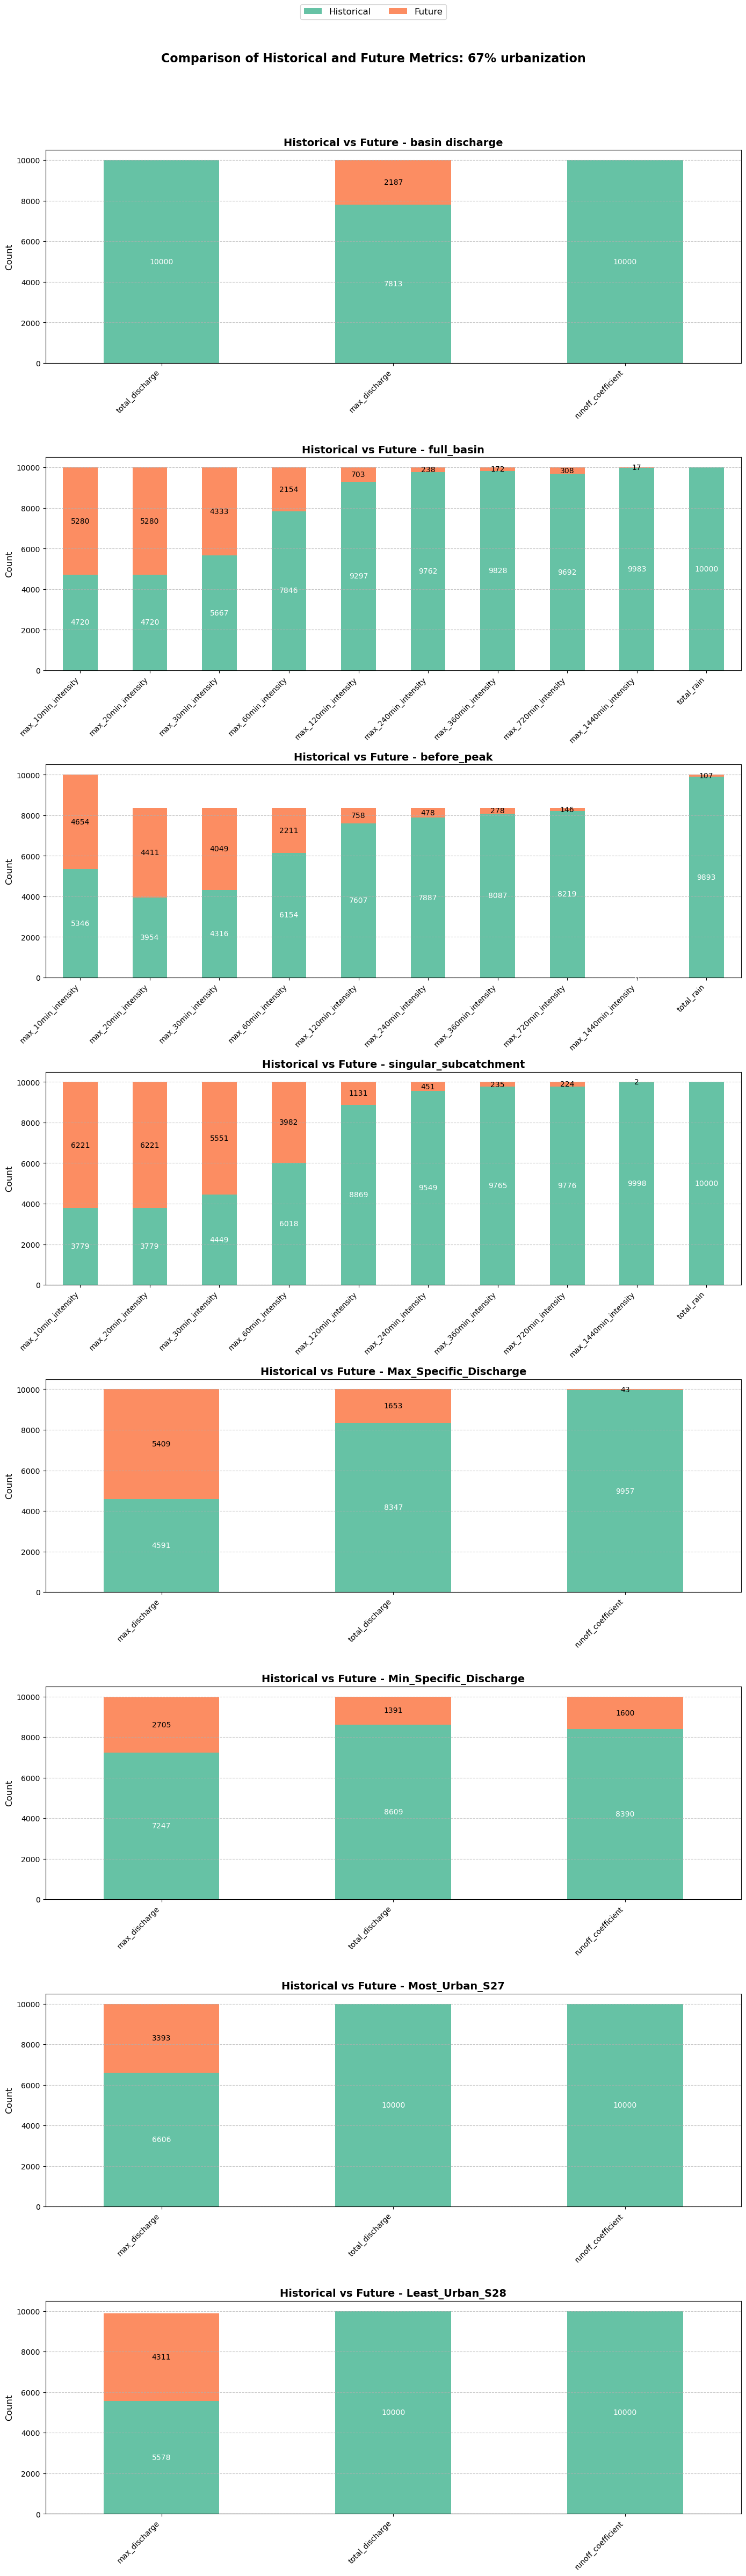

In [14]:
# Exclude specific metrics
excluded_metric = ('basin discharge', 'swmm_max_outflow_time')

# Automatically group metrics by the top-level category
categories = {}
for (category, metric) in all_events_direc_df.index:
    if (category, metric) != excluded_metric:  # Skip excluded metric
        categories.setdefault(category, []).append(metric)

# Define bar colors
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Create subplots dynamically
fig, axes = plt.subplots(len(categories), 1, figsize=(14, len(categories) * 6), sharey=True)

# Iterate through categories and plot each group
for ax, (category, metrics) in zip(axes, categories.items()):
    # Filter data for the current category
    subset = all_events_direc_df.loc[[(category, metric) for metric in metrics]]
    
    # Plot the stacked bar chart
    subset[['historical_count', 'future_count']].plot(
        kind='bar',
        stacked=True,
        color=[historical_color, future_color],
        ax=ax,
        legend=False
    )
    
    # Annotate counts
    for i, metric in enumerate(metrics):
        hist_count = subset['historical_count'].iloc[i]
        fut_count = subset['future_count'].iloc[i]
        ax.text(i, hist_count / 2, f'{hist_count}', ha='center', va='center', fontsize=10, color='white')
        if fut_count > 0:
            ax.text(i, hist_count + fut_count / 2, f'{fut_count}', ha='center', va='center', fontsize=10, color='black')

    # Customize subplot
    ax.set_title(f'Historical vs Future - {category}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')  # Remove x-axis label
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=10)  # Show only the lower-level metric names
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add a global legend
fig.legend(['Historical', 'Future'], loc='upper center', ncol=2, fontsize=12)

# Adjust layout to fit everything
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle(
    f"Comparison of Historical and Future Metrics: {rain_shift_classes[rain_shift_idx][-1]}",
    fontsize=16, 
    fontweight='bold'
)


# Save and show the plot
subplot_path = os.path.join(save_dir, 'historical_vs_future_subplot.png')
plt.savefig(subplot_path, dpi=300)
plt.show()


#### Dive into one metric from the direction bar plot

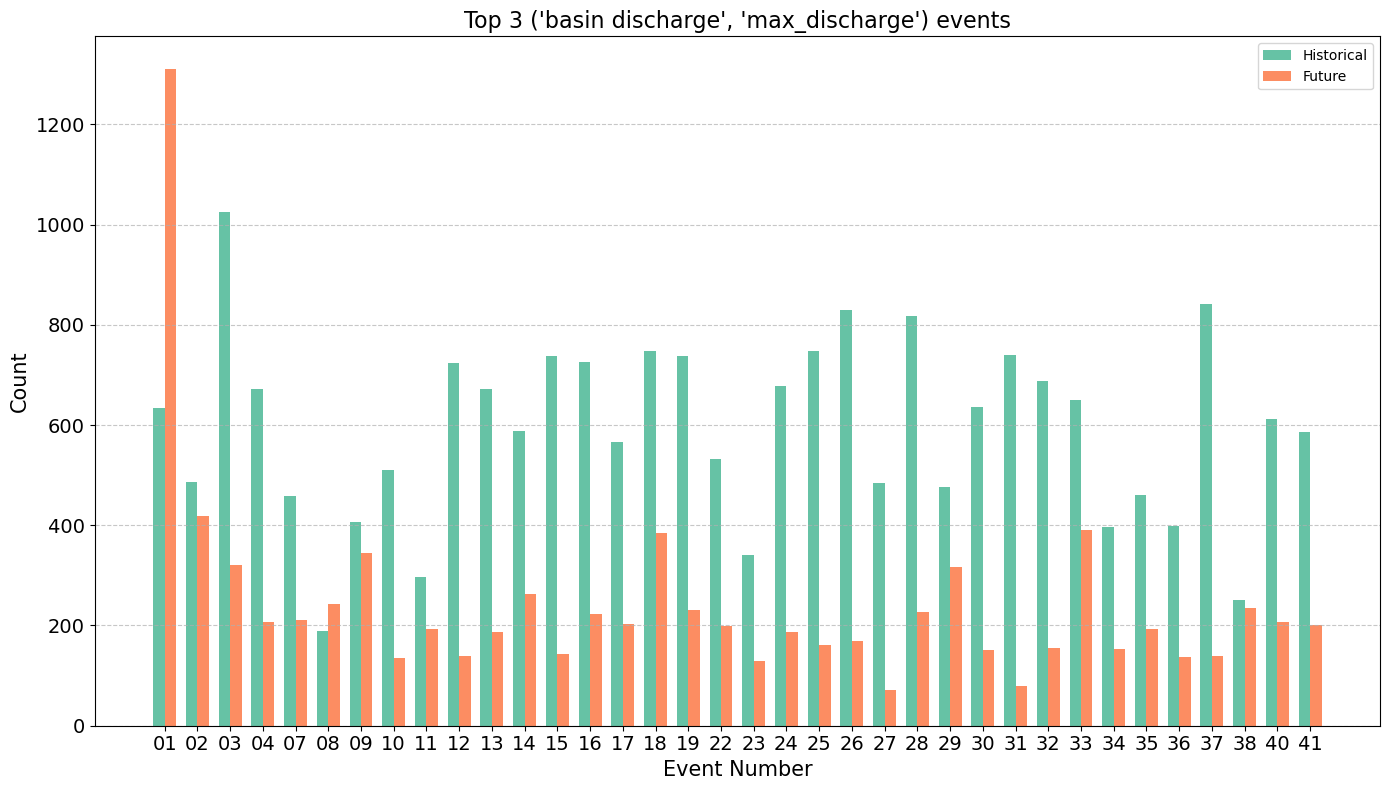

In [15]:
metric = ('basin discharge', 'max_discharge')
# Retrieve top events
historical_top_3_events = all_events_direc_df.loc[metric]['historical_top_3_events']
future_top_3_events = all_events_direc_df.loc[metric]['future_top_3_events']

# Combine the keys of both Counters and sort them
all_events = sorted(set(future_top_3_events.keys()).union(historical_top_3_events.keys()), key=int)

# Create lists for the counts, ensuring alignment with the sorted event numbers
future_counts = [future_top_3_events.get(event, 0) for event in all_events]
historical_counts = [historical_top_3_events.get(event, 0) for event in all_events]

# Plotting
x = np.arange(len(all_events))  # the label locations
width = 0.35  # the width of the bars

historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, historical_counts, width, label='Historical', color=historical_color)
rects2 = ax.bar(x + width/2, future_counts, width, label='Future', color=future_color)

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Event Number', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title(f'Top 3 {metric} events', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(all_events)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(rotation=0, fontsize=14)
ax.legend()

# Add a grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot with tight layout
plt.tight_layout()
topbar_path = os.path.join(save_dir, f'top_{metric}_bar_plot.png')
plt.savefig(topbar_path)
plt.show()


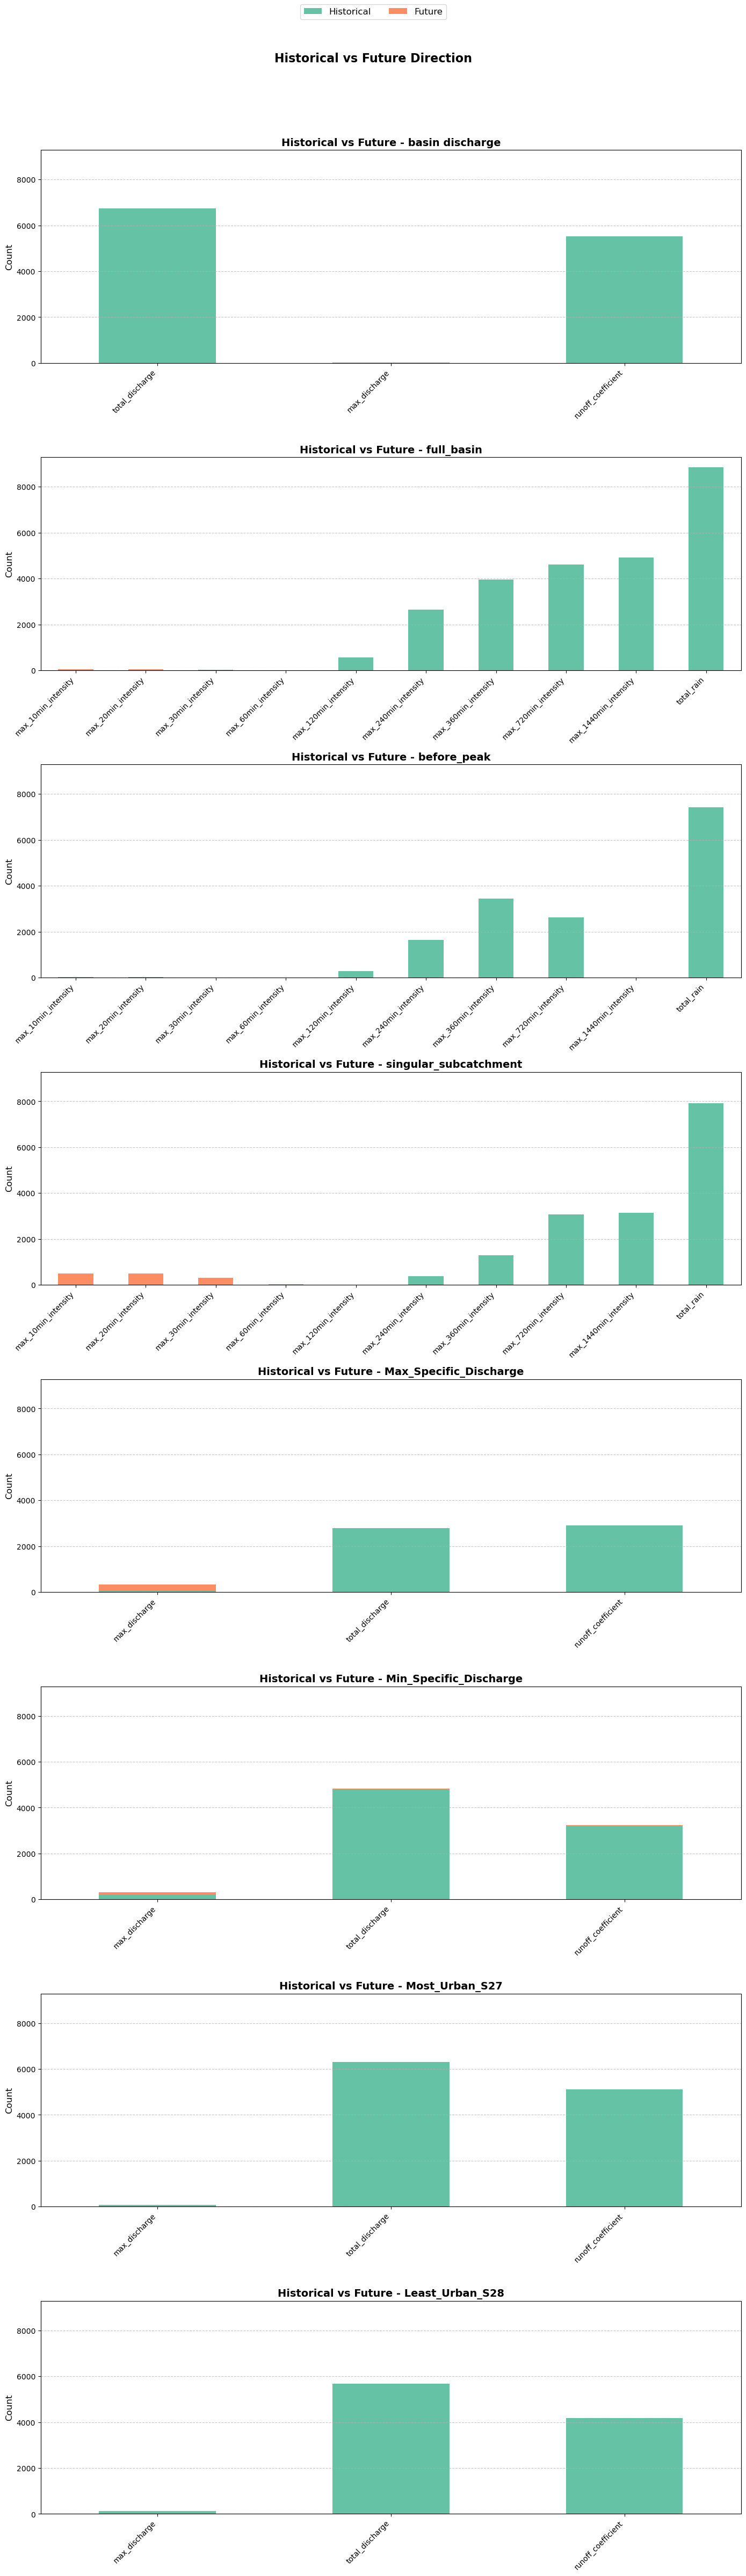

In [16]:
# Define colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Automatically group parameters by the top-level category
categories = {}
for (category, metric) in significant_events_direc_df.index:
    categories.setdefault(category, []).append(metric)

# Create subplots dynamically
fig, axes = plt.subplots(len(categories), 1, figsize=(14, len(categories) * 6), sharey=True)

# Iterate through categories and plot each group
for ax, (category, metrics) in zip(axes, categories.items()):
    # Filter data for the current category
    subset = significant_events_direc_df.loc[[(category, metric) for metric in metrics]]
    
    # Plot the stacked bar chart
    subset[['historical_count', 'future_count']].plot(
        kind='bar',
        stacked=True,
        color=[historical_color, future_color],
        ax=ax,
        legend=False
    )
    
#     # Annotate counts
#     for i, metric in enumerate(metrics):
#         hist_count = subset['historical_count'].iloc[i]
#         fut_count = subset['future_count'].iloc[i]
        
#         if hist_count + fut_count < 2000:
#             ax.text(
#                 i,
#                 hist_count + 300,
#                 f'historical: {hist_count}',
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#                 color='black'
#             )
#             ax.text(
#                 i,
#                 hist_count + 600,
#                 f'future: {fut_count}',
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#                 color='black'
#             )
#         else:
#             ax.text(
#                 i,
#                 hist_count / 2,
#                 f'{hist_count}',
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#                 color='black'
#             )
#             ax.text(
#                 i,
#                 hist_count + fut_count / 2,
#                 f'{fut_count}',
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#                 color='black'
#             )

    # Customize subplot
    ax.set_title(f'Historical vs Future - {category}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')  # Remove x-axis label
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=10)  # Use lower-level metric names
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add a global legend
fig.legend(['Historical', 'Future'], loc='upper center', ncol=2, fontsize=12)

# Adjust layout and add a global title
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle('Historical vs Future Direction', fontsize=16, fontweight='bold')

# Save and show the plot
significant_barplot_path = os.path.join(save_dir, f'significant_events_direction_bar_plot_{distrbution_names_l[distrbution_idx]}.png')
plt.savefig(significant_barplot_path, dpi=300)
plt.show()


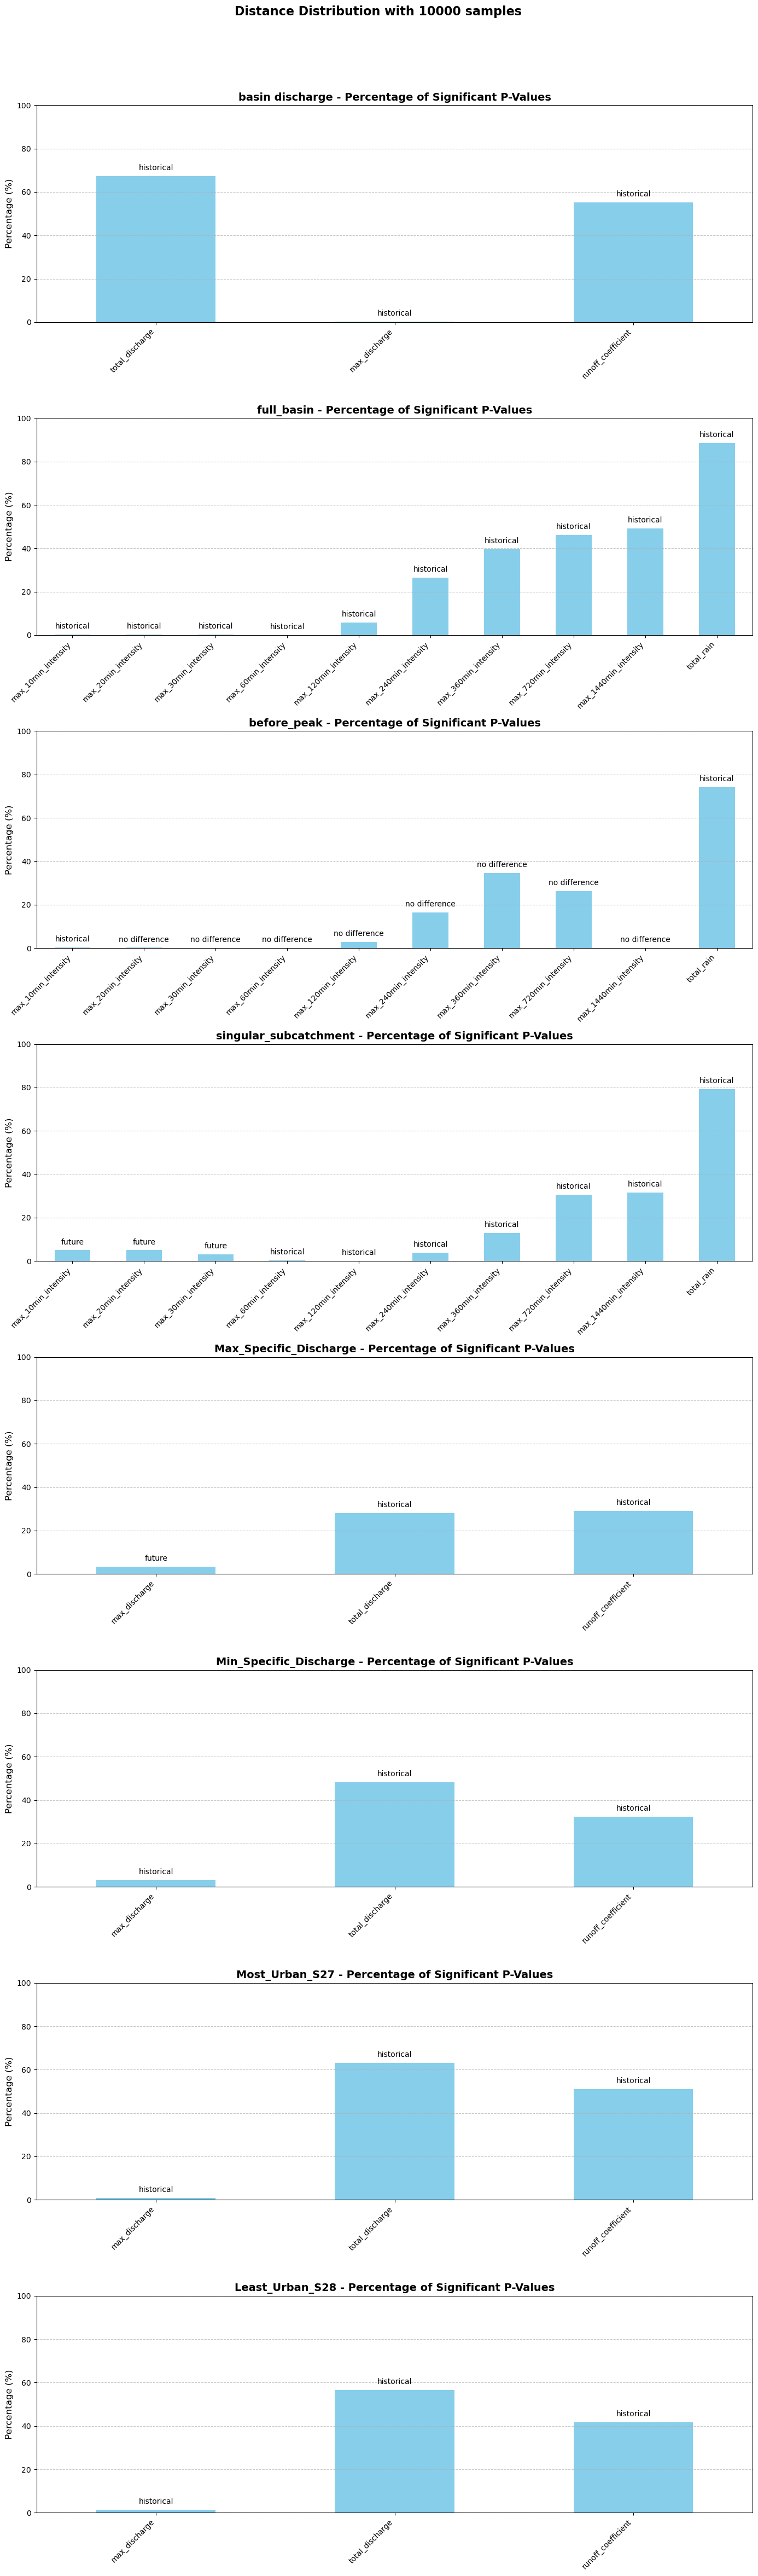

In [17]:
# Exclude specific metrics (if necessary)
# excluded_metric = ('some_category', 'some_metric')  # Define exclusions if needed

# Automatically group parameters by the top-level category
categories = {}
for (category, metric) in significant_events_direc_df.index:
    # if (category, metric) != excluded_metric:  # Skip excluded metric (if applicable)
    categories.setdefault(category, []).append(metric)

# Define plot settings
bar_color = 'skyblue'

# Create subplots dynamically
fig, axes = plt.subplots(len(categories), 1, figsize=(14, len(categories) * 6), sharey=True)

# Iterate through categories and plot each group
for ax, (category, metrics) in zip(axes, categories.items()):
    # Filter data for the current category
    subset = significant_events_direc_df.loc[[(category, metric) for metric in metrics]]
    
    # Plot the bar chart
    subset['percentage_p_value < 0.05 (%)'].plot(
        kind='bar',
        color=bar_color,
        ax=ax
    )
    
    # Annotate direction
    for i, direction in enumerate(subset['direction']):
        ax.text(
            i,
            subset['percentage_p_value < 0.05 (%)'][i] + 2,
            direction,
            ha='center',
            va='bottom',
            fontsize=10
        )

    # Customize subplot
    ax.set_title(f'{category} - Percentage of Significant P-Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('')  # Remove x-axis label
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=10)  # Show only the lower-level metric names
    ax.set_ylim(0, 100)  # Set percentage range
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and add a global title
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle(f'{distrbution_names_l[distrbution_idx]} with {n} samples', fontsize=16, fontweight='bold')

# Save and show the plot
significant_barplot_path = os.path.join(save_dir, f'significant_events_main_direction_bar_plot_{distrbution_names_l[distrbution_idx]}.png')
plt.savefig(significant_barplot_path, dpi=300)
plt.show()
